In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openquake.commonlib.datastore import read

In [2]:
!oq engine --lrc

job_id |     status |          start_time |         description
     1 |   complete | 2024-11-03 12:06:15.308445 | Scenario Risk Demo (Catania Tsunami) using hysea simulation no aggregation
     2 |   complete | 2024-11-03 12:06:35.087976 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 892 no aggregation
     3 |   complete | 2024-11-03 12:06:54.806854 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 1658 no aggregation
     4 |   complete | 2024-11-03 12:07:16.469549 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 3454 no aggregation
     5 |   complete | 2024-11-03 12:12:18.075475 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 7071 no aggregation
     6 |   complete | 2024-11-03 13:17:53.362380 | Scenario Risk Demo (Catania Tsunami) using hysea simulation with foglio aggregation
     7 |   complete | 2024-11-03 13:19:15.386250 | Scenario Risk Demo (C

In [9]:
dstore = read(79)
list(dstore)

['agg_values',
 'assetcol',
 'avg_losses-rlzs',
 'complete',
 'crm',
 'discarded',
 'events',
 'exposure',
 'full_lt',
 'gmf_data',
 'oqparam',
 'performance_data',
 'risk_by_event',
 'rupgeoms',
 'ruptures',
 'sitecol',
 'task_info',
 'task_sent',
 'taxmap',
 'weights']

In [10]:
dstore.read_df('risk_by_event')

,event_id,agg_id,loss_id,variance,loss
0,0,0,3,0.0,5468.233887


In [ ]:
file = '/home/naveen.raguramalinga/oqdata/calc_70.hdf5'
with h5py.File(file, 'r') as f:
    for name in f:
        obj = f[name]
        print(f"Dataset: {name}")
        print("Data:")
        print(obj)  # Print the actual data

In [ ]:
def print_hdf5_content(obj, name):
    """
    A recursive function to print the content of an HDF5 file.
    """
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
        for key, item in obj.items():
            print_hdf5_content(item, f"{name}/{key}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}")
        print(f"Shape: {obj.shape}, Dtype: {obj.dtype}")
        print("Data:")
        print(obj)  # Print the actual data
    else:
        print(f"Unknown type: {name}")

with h5py.File(file, "r") as f:
    print_hdf5_content(f, '/')

In [3]:
risk_event_gmf = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/tmp/risk_by_event_66.csv',header=1)
risk_event_imt = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/tmp/risk_by_event_103.csv',header=1)

event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

mean_rate = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/all_eventsBS_PS53550_meanrate.txt',header=0)
mean_rate.columns = ['eve_id','mean_rate']

#link event info with risk event using event_id, keep all events in event_info
event_table = pd.merge(event_info,risk_event_gmf,on='event_id',how='left')
event_table['loss_gmf'] = event_table['loss']
event_table = event_table.drop(columns=['loss'])
event_table = event_table.drop(columns=['loss_type'])

event_table = pd.merge(event_table,risk_event_imt,on='event_id',how='left')
event_table['loss_imt'] = event_table['loss']
event_table = event_table.drop(columns=['loss'])
event_table = event_table.drop(columns=['loss_type'])

#set missing values to 0
event_table['loss_gmf'] = event_table['loss_gmf'].fillna(0)
event_table['loss_imt'] = event_table['loss_imt'].fillna(0)

#set values less than 100 to 0
event_table['loss_gmf'] = np.where(event_table['loss_gmf']<500,0,event_table['loss_gmf'])
event_table['loss_imt'] = np.where(event_table['loss_imt']<500,0,event_table['loss_imt'])

print(np.count_nonzero(event_table['loss_gmf']), 'events have loss in GMF')
print(np.count_nonzero(event_table['loss_imt']), 'events have loss in IMT')

#add mean rate to event table
event_table = pd.merge(event_table,mean_rate,on='eve_id',how='left')


30168 events have loss in GMF
30168 events have loss in IMT


In [4]:
loss = event_table['loss_gmf'] #loss for event(L)
rate = event_table['mean_rate'] #mean annual rate for event(p)

#sort descending
idx = np.argsort(loss)[::-1]
sorted_loss = loss[idx]
sorted_rate = rate[idx]

#Event loss table
ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
ELT['weighted_loss'] = sorted_loss*sorted_rate
ELT['cumulative_probability'] = ELT['rate'].cumsum()

AAL = np.sum(ELT['weighted_loss'])
print('AAL:',AAL)

#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10,100,1000,10000,100000,1000000,10000000,100000000]
PoE = [1/rp for rp in RP]

PML_gmf = np.zeros(len(PoE))
#find the event loss for each RP
for i,probability_level in enumerate(PoE):
    PML_gmf[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()



AAL: 18965.237277084074


In [5]:
loss = event_table['loss_imt'] #loss for event(L)
rate = event_table['mean_rate'] #mean annual rate for event(p)

#sort descending
idx = np.argsort(loss)[::-1]
sorted_loss = loss[idx]
sorted_rate = rate[idx]

#Event loss table
ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
ELT['weighted_loss'] = sorted_loss*sorted_rate
ELT['cumulative_probability'] = ELT['rate'].cumsum()

AAL = np.sum(ELT['weighted_loss'])
print('AAL:',AAL)

#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10,100,1000,10000,100000,1000000,10000000,100000000]
PoE = [1/rp for rp in RP]

PML_imt = np.zeros(len(PoE))
#find the event loss for each RP
for i,probability_level in enumerate(PoE):
    PML_imt[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()




AAL: 18965.237277084074


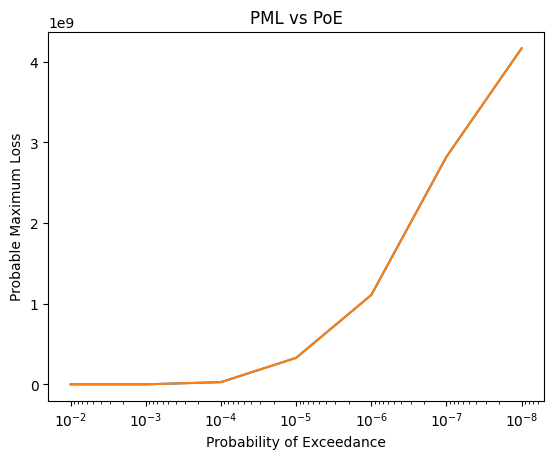

In [9]:
#plot
fig, ax = plt.subplots()
ax.plot(PoE,PML_imt,label='FLOWDEPTH')
ax.plot(PoE,PML_gmf,label='PGA')
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Probability of Exceedance')
ax.set_ylabel('Probable Maximum Loss')
ax.set_title('PML vs PoE')
#reverse x-axis
ax.invert_xaxis()
plt.show()


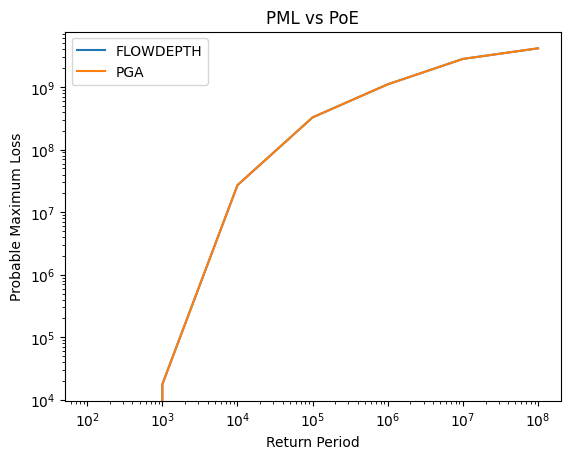

In [7]:
#plot
fig, ax = plt.subplots()
ax.plot(RP,PML_imt,label='FLOWDEPTH')
ax.plot(RP,PML_gmf,label='PGA')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Return Period')
ax.set_ylabel('Probable Maximum Loss')
ax.set_title('PML vs PoE')
ax.legend()
plt.show()
